<h1 style="text-align:center; color:#2E86C1;">💤 Sleep Health & Lifestyle Analytics</h1>

<hr>

<h2 style="color:#2E86C1;">Dataset Overview</h2>
<p>
This dataset provides a comprehensive look at the physiological and behavioral factors affecting human sleep. It tracks a diverse group of individuals, measuring their daily activity, stress levels, and biological markers to understand what truly defines "good sleep."
</p>

<h3 style="color:#2E86C1;">1. Demographic & Personal Background</h3>
<ul>
    <li><b>Person ID:</b> Unique identifier for each participant.</li>
    <li><b>Age:</b> Age of the participant (Years). <i>Biological impact on sleep architecture.</i></li>
    <li><b>Gender:</b> Biological sex (Male/Female).</li>
    <li><b>Occupation:</b> Professional field (e.g., Software Engineer, Doctor, Driver).</li>
    <li><b>Country:</b> Geographical location, which can influence lifestyle habits.</li>
    <li><b>BMI (Body Mass Index):</b> Measures body fat based on height and weight.</i>
    </li>
</ul>

<h3 style="color:#2E86C1;">2. Sleep Architecture & Metrics</h3>
<ul>
    <li><b>Sleep Duration (hrs):</b> Total time spent sleeping.</li>
    <li><b>Sleep Qualty Score:</b>A comprehensive rating ranging from <b>1 to 10</b> that quantifies the overall excellence of the sleep session.</li>
    <li><b>REM Percentage:</b> Percentage of sleep spent in Rapid Eye Movement (dreaming phase).</li>
    <li><b>Deep Sleep Percentage:</b> Percentage of "Slow Wave Sleep" (physical recovery phase).</li>
    <li><b>Sleep Latency (mins):</b> The time it takes to fall asleep after turning off the lights.</li>
    <li><b>Wake Episodes:</b> Number of times the person woke up during the night.</li>
</ul>

<h3 style="color:#2E86C1;">3. Daily Lifestyle</h3>
<ul>
    <li><b>Caffeine Intake (mg):</b> Total caffeine consumed before bed.</li>
    <li><b>Alcohol Units:</b> Amount of alcohol consumed, which often fragments sleep.</li>
    <li><b>Screen Time (mins):</b> Exposure to blue light before sleep.</li>
    <li><b>Exercise Day:</b> Binary indicator (1: Exercised, 0: No).</li>
    <li><b>Steps:</b> Total physical activity measured in step count.</li>
    <li><b>Nap Duration (mins):</b> Length of daytime sleep (can affect nighttime latency).</li>
</ul>

<h3 style="color:#2E86C1;">4. Psychological</h3>
<ul>
    <li><b>Stress Score (1-10):</b> Subjective or measured psychological pressure.</li>
    <li><b>Work Hours:</b> Total hours spent on professional tasks.</li>
    <li><b>Chronotype:</b> Biological clock (Morning, Evening, or Neutral).</li>
    <li><b>Mental Health Condition:</b> Existing conditions (e.g., Anxiety, Healthy).</li>
</ul>

<h3 style="color:#2E86C1;">5. Health Context</h3>
<ul>
    <li><b>Heart Rate (Resting):</b> Baseline BPM, an indicator of autonomic nervous system state.</li>
    <li><b>Sleep Aids Used:</b> Indicates whether the individual used a sleep aid (e.g., medication or supplements); (0: No, 1: Yes).</li>
    <li><b>Shift Work:</b> Indicates if the person works irregular hours/night shifts.</li>
    <li><b>Room Temperature (°C):</b> The thermal environment of the bedroom.</li>
    <li><b>Weekend Sleep Diff (Hrs):</b> Measures the difference (in hours) between sleep timing on workdays vs. weekends.</li>
</ul>

<h3 style="color:#2E86C1;">6. Environmental & Psychological Factors</h3>
<ul>
    <li><b>Season:</b> Time of year (Winter, Summer, etc.), affecting light and heat.</li>
    <li><b>Day Type:</b> (Weekend, Weekday).</li>
</ul>

<hr>

<h3 style="color:#2E86C1;">Target Variables (The Predictions)</h3>

<table style="width:100%; border: 1px solid #ddd; border-collapse: collapse;">
  <tr>
    <td style="padding: 10px; border: 1px solid #ddd;"><b>Cognitive performance score</b></td>
    <td style="padding: 10px; border: 1px solid #ddd; color: #E67E22;"><b>Regression</b></td>
    <td style="padding: 10px; border: 1px solid #ddd;">Predicting a continuous value (0-100) based on sleep efficiency and architecture.</td>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid #ddd;"><b>Sleep Disorder Risk</b></td>
    <td style="padding: 10px; border: 1px solid #ddd; color: #27AE60;"><b>Classification</b></td>
    <td style="padding: 10px; border: 1px solid #ddd;">Categorizing the risk level (Healthy, Mild, Moderate, Severe).</td>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid #ddd;"><b>Felt Rested</b></td>
    <td style="padding: 10px; border: 1px solid #ddd; color: #27AE60;"><b>Binary Classification</b></td>
    <td style="padding: 10px; border: 1px solid #ddd;">A Binary outcome (0: No, 1: Yes) reflecting the subjective feeling upon waking.</td>
  </tr>
</table>

# Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, RobustScaler
from category_encoders import OneHotEncoder, BinaryEncoder, OrdinalEncoder
from sklearn.utils import resample
from sklearn.feature_selection import f_classif, chi2
from scipy.stats import spearmanr, chi2_contingency, pointbiserialr
from sklearn.feature_selection import SelectKBest

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

import math
import warnings
warnings.filterwarnings('ignore')

# Data Overview

In [15]:
df=pd.read_csv(r"sleep_health_dataset.csv")
df.shape

(100000, 32)

In [16]:
def data_info(data):
    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]



    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,})
    return info_df
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls
0,person_id,int64,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",100000,0,0.0
1,age,int64,"[27, 26, 25, 23, 24, 31, 34, 28, 32, 33]",52,0,0.0
2,gender,object,"[Female, Male, Other]",3,0,0.0
3,occupation,object,"[Student, Software Engineer, Nurse, Manager, T...",12,0,0.0
4,bmi,float64,"[16.0, 25.5, 27.8, 25.6, 27.0, 25.3, 26.3, 26....",277,0,0.0
5,country,object,"[USA, India, Japan, UK, Brazil, Germany, Canad...",15,0,0.0
6,sleep_duration_hrs,float64,"[5.93, 6.41, 5.89, 6.19, 5.99, 6.52, 6.13, 6.4...",750,0,0.0
7,sleep_quality_score,float64,"[4.8, 5.3, 5.1, 5.0, 5.4, 4.7, 5.2, 5.6, 4.9, ...",89,0,0.0
8,rem_percentage,float64,"[20.3, 19.6, 20.7, 20.0, 19.7, 21.0, 20.5, 20....",201,0,0.0
9,deep_sleep_percentage,float64,"[30.0, 20.1, 20.2, 21.1, 20.8, 19.6, 20.4, 19....",251,0,0.0


<ul>
    <li>Delete person_id column.</li>
    <li>Country Column Logic: If "Egypt" is found, remove all other rows (filter to keep only Egypt), then drop the country column. If "Egypt" is not present, simply drop the column.</li>
    <li>Drop rem_percentage: Since it cannot be accurately calculated or filled with a default value.</li>
    <li>Drop room_temp: Remove the column as it is difficult to measure accurately.</li>
    <li>Drop heart_rate: Remove the column because it cannot be measured..</li>
    <li>Cast alcohol_units_before_bed to int.</li>
</ul>

In [4]:
df.describe().T.style.bar(subset=['mean'], color='#FFA07A').background_gradient(
    subset=['std', '50%', 'max'], cmap='Blues').set_properties(
        **{'font-size': '12pt', 'border': '1.5px solid black'}).set_caption("🔍 Summary Statistics of the Dataset")

,count,mean,std,min,25%,50%,75%,max
person_id,100000.000000,50000.500000,28867.657797,1.000000,25000.750000,50000.500000,75000.250000,100000.000000
age,100000.000000,34.706870,11.036373,18.000000,26.000000,33.000000,42.000000,69.000000
bmi,100000.000000,26.289673,4.479578,16.000000,23.200000,26.300000,29.300000,45.000000
sleep_duration_hrs,100000.000000,6.423986,1.274627,3.000000,5.530000,6.360000,7.270000,10.500000
sleep_quality_score,100000.000000,4.871144,1.506517,1.000000,3.800000,4.900000,6.000000,10.000000
rem_percentage,100000.000000,20.243968,3.411354,10.000000,18.000000,20.300000,22.600000,30.000000
deep_sleep_percentage,100000.000000,20.253375,4.251096,5.000000,17.400000,20.300000,23.200000,30.000000
sleep_latency_mins,100000.000000,19.836810,7.584343,1.000000,14.000000,19.000000,25.000000,58.000000
wake_episodes_per_night,100000.000000,3.346610,1.920877,0.000000,2.000000,3.000000,5.000000,8.000000
caffeine_mg_before_bed,100000.000000,38.849500,69.395818,0.000000,0.000000,0.000000,80.000000,400.000000


# Data Analysis and Visualizations

## target visualize

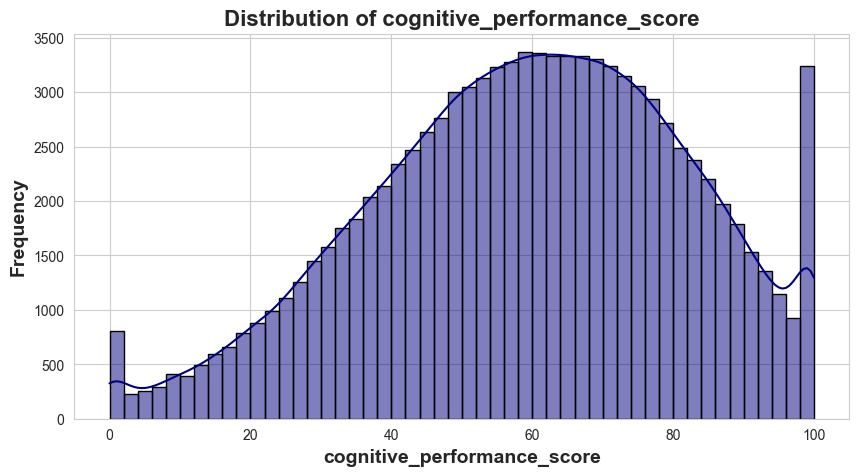

In [5]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))

sns.histplot(df["cognitive_performance_score"], bins=50, kde=True, color="navy", edgecolor="black")

plt.xlabel("cognitive_performance_score", fontsize=14, fontweight='bold')
plt.ylabel("Frequency", fontsize=14, fontweight='bold')
plt.title("Distribution of cognitive_performance_score", fontsize=16, fontweight='bold')

plt.show()

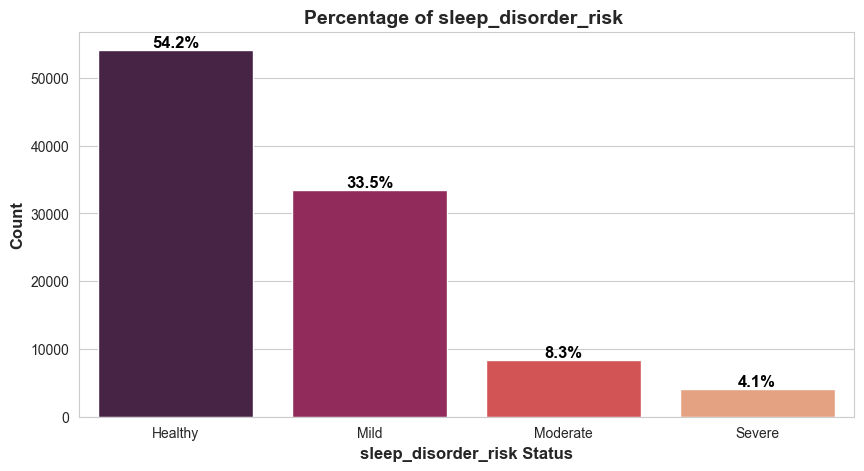

In [6]:
sns.set_style("whitegrid")
sleep_disorder_risk_counts = df["sleep_disorder_risk"].value_counts(normalize=True)*100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=sleep_disorder_risk_counts.index, y=df["sleep_disorder_risk"].value_counts(), palette="rocket")

plt.title("Percentage of sleep_disorder_risk ", fontsize=14, fontweight='bold')
plt.xlabel("sleep_disorder_risk Status", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')

for p, percentage in zip(ax.patches, sleep_disorder_risk_counts.values):
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black')
plt.show()

<ul>
    <li>need to balance the data</li>
</ul>

## feature visualize

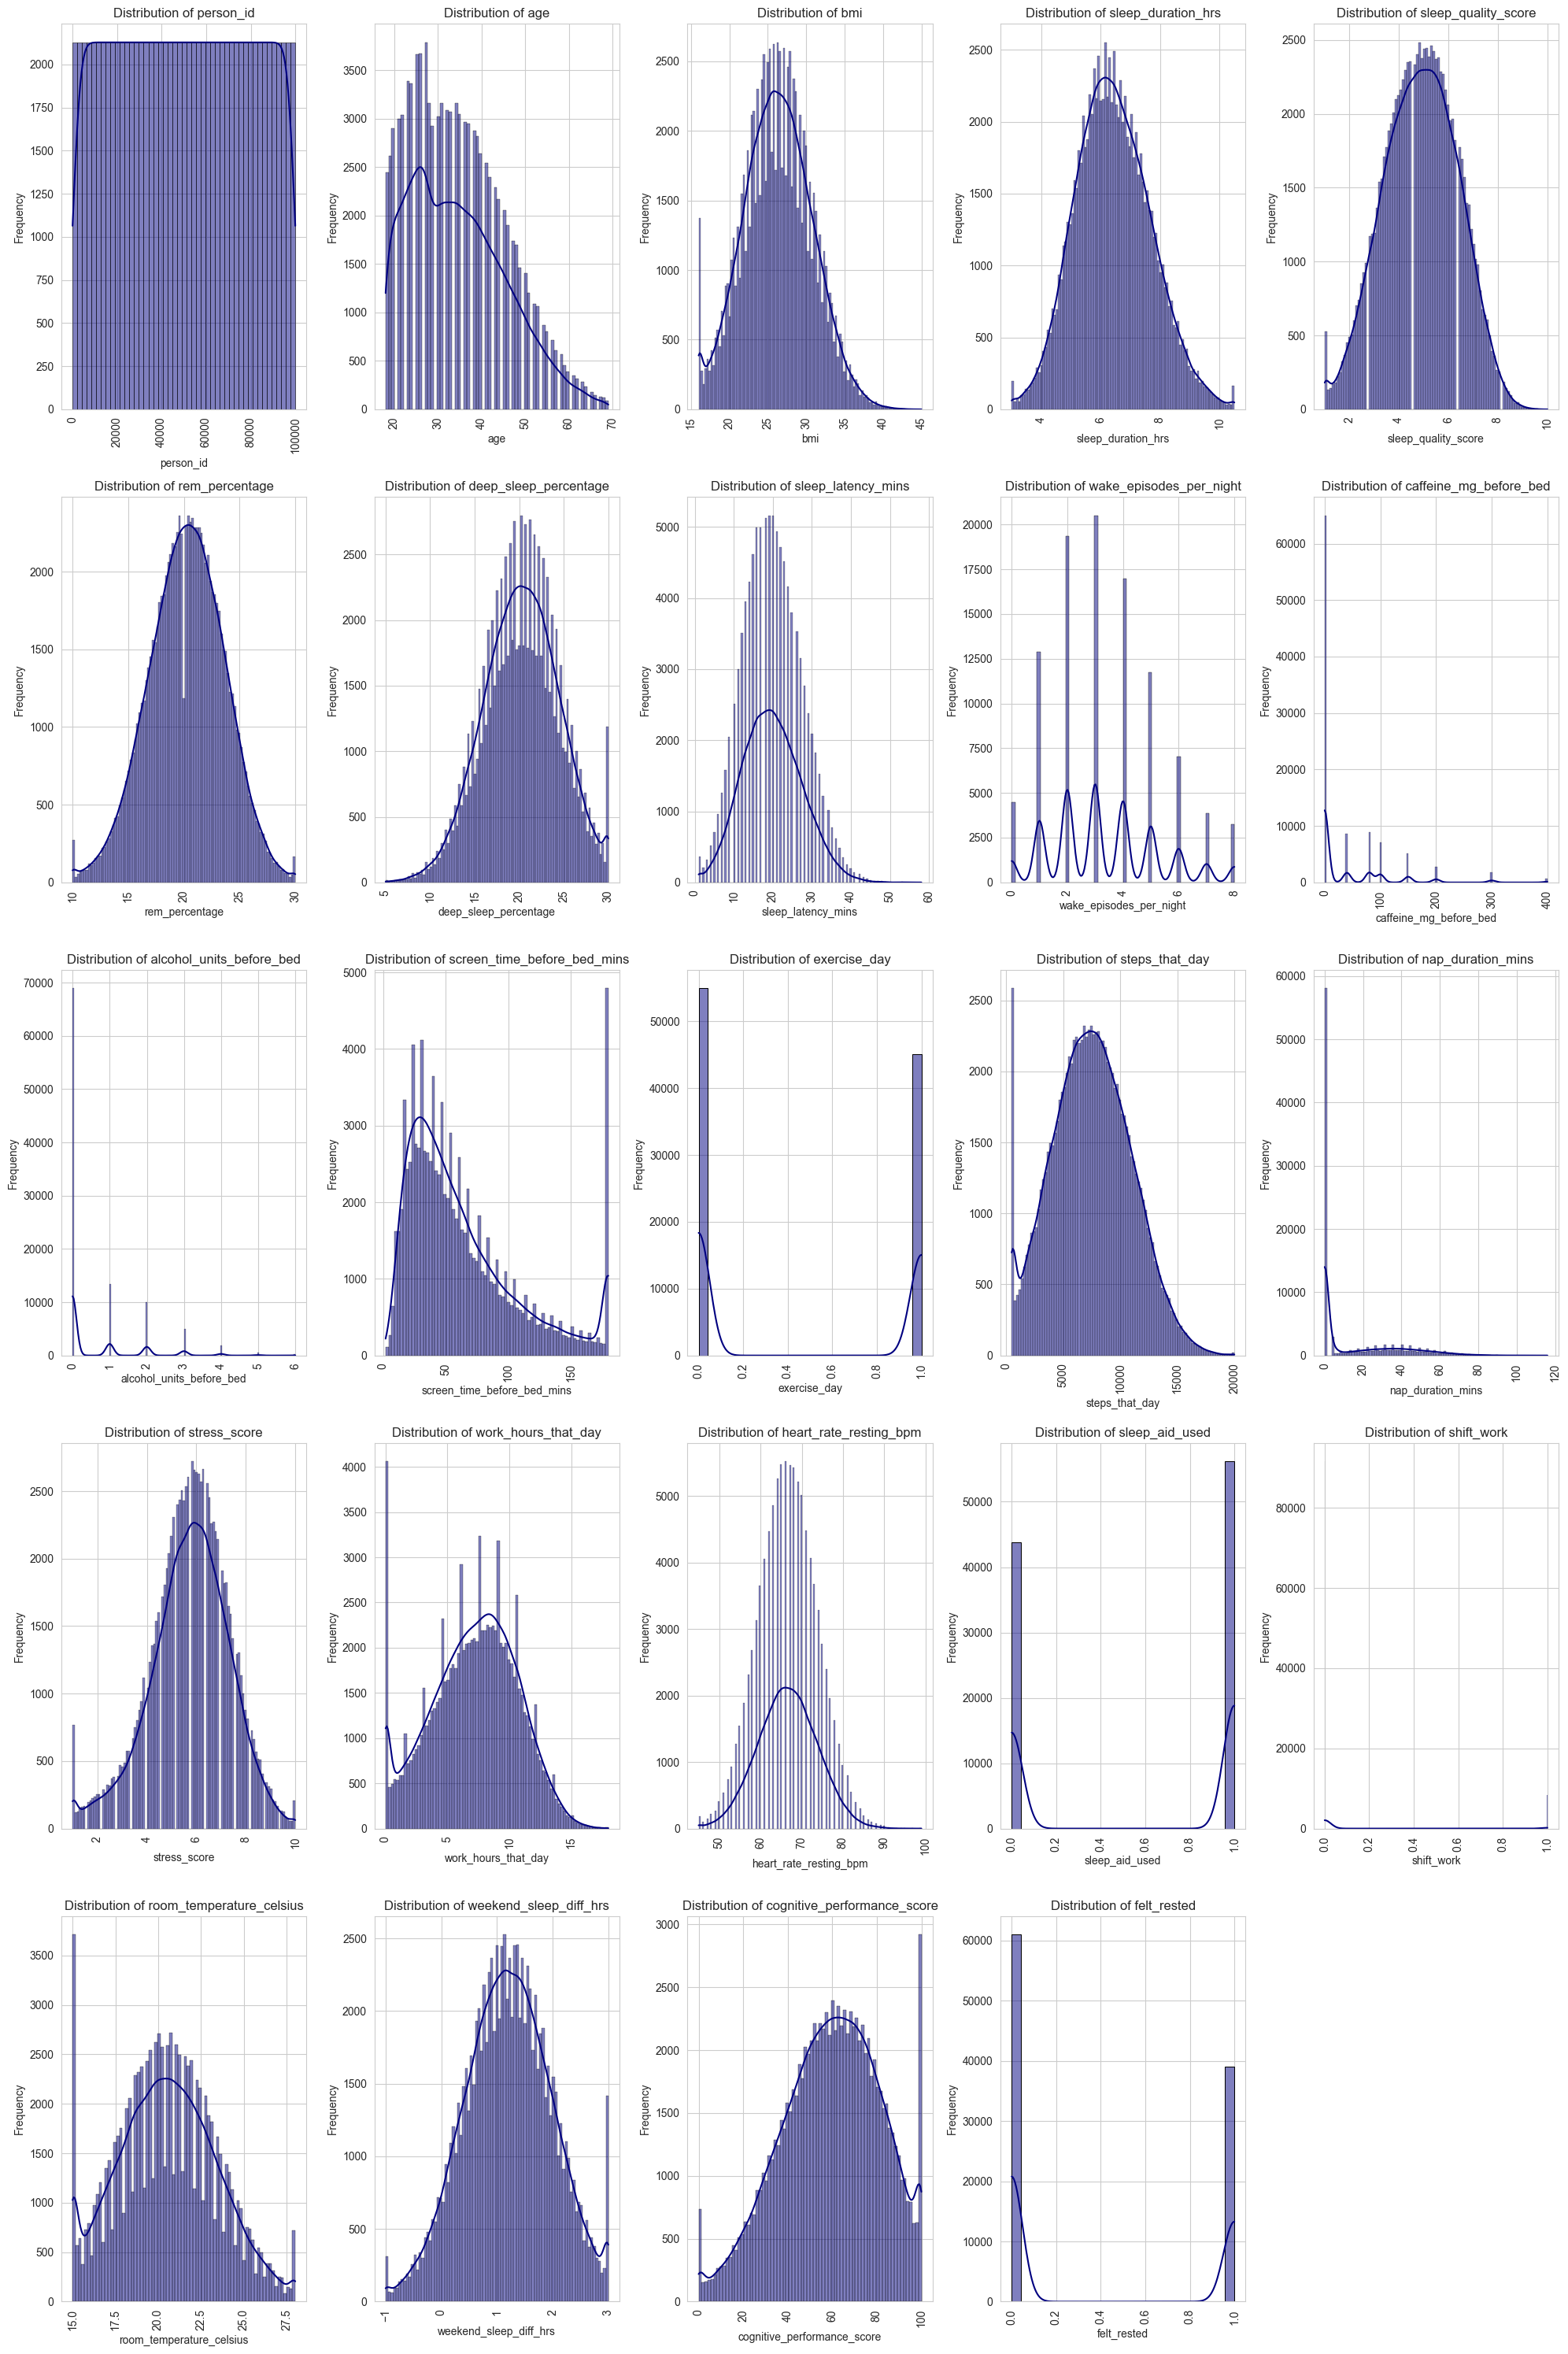

In [7]:
numerical =df.select_dtypes(include=['int64', 'float64']).columns
fig, axes = plt.subplots(5, 5, figsize=(20, 30))
axes = axes.flatten()
for i, col in enumerate(numerical) :
    sns.histplot(data=df, x=col, ax=axes[i], kde=True, color="navy", edgecolor="black")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=90)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])     
plt.tight_layout()
plt.show()

<ul>
    <li>caffeine_mg_before_bed and alcohol_units_before_bed: Convert it into a binary feature (0 or 1).</li>
    <li>bmi, sleep_duration_hrs, stress_score, heart_rate_resting_bpm and rem_percentage are normal distribution.</li>
    <li>over 4,000 individuals spend more than 120 minutes on their phones before sleep.</li>
    <li>most people do not take naps.</li>
</ul>

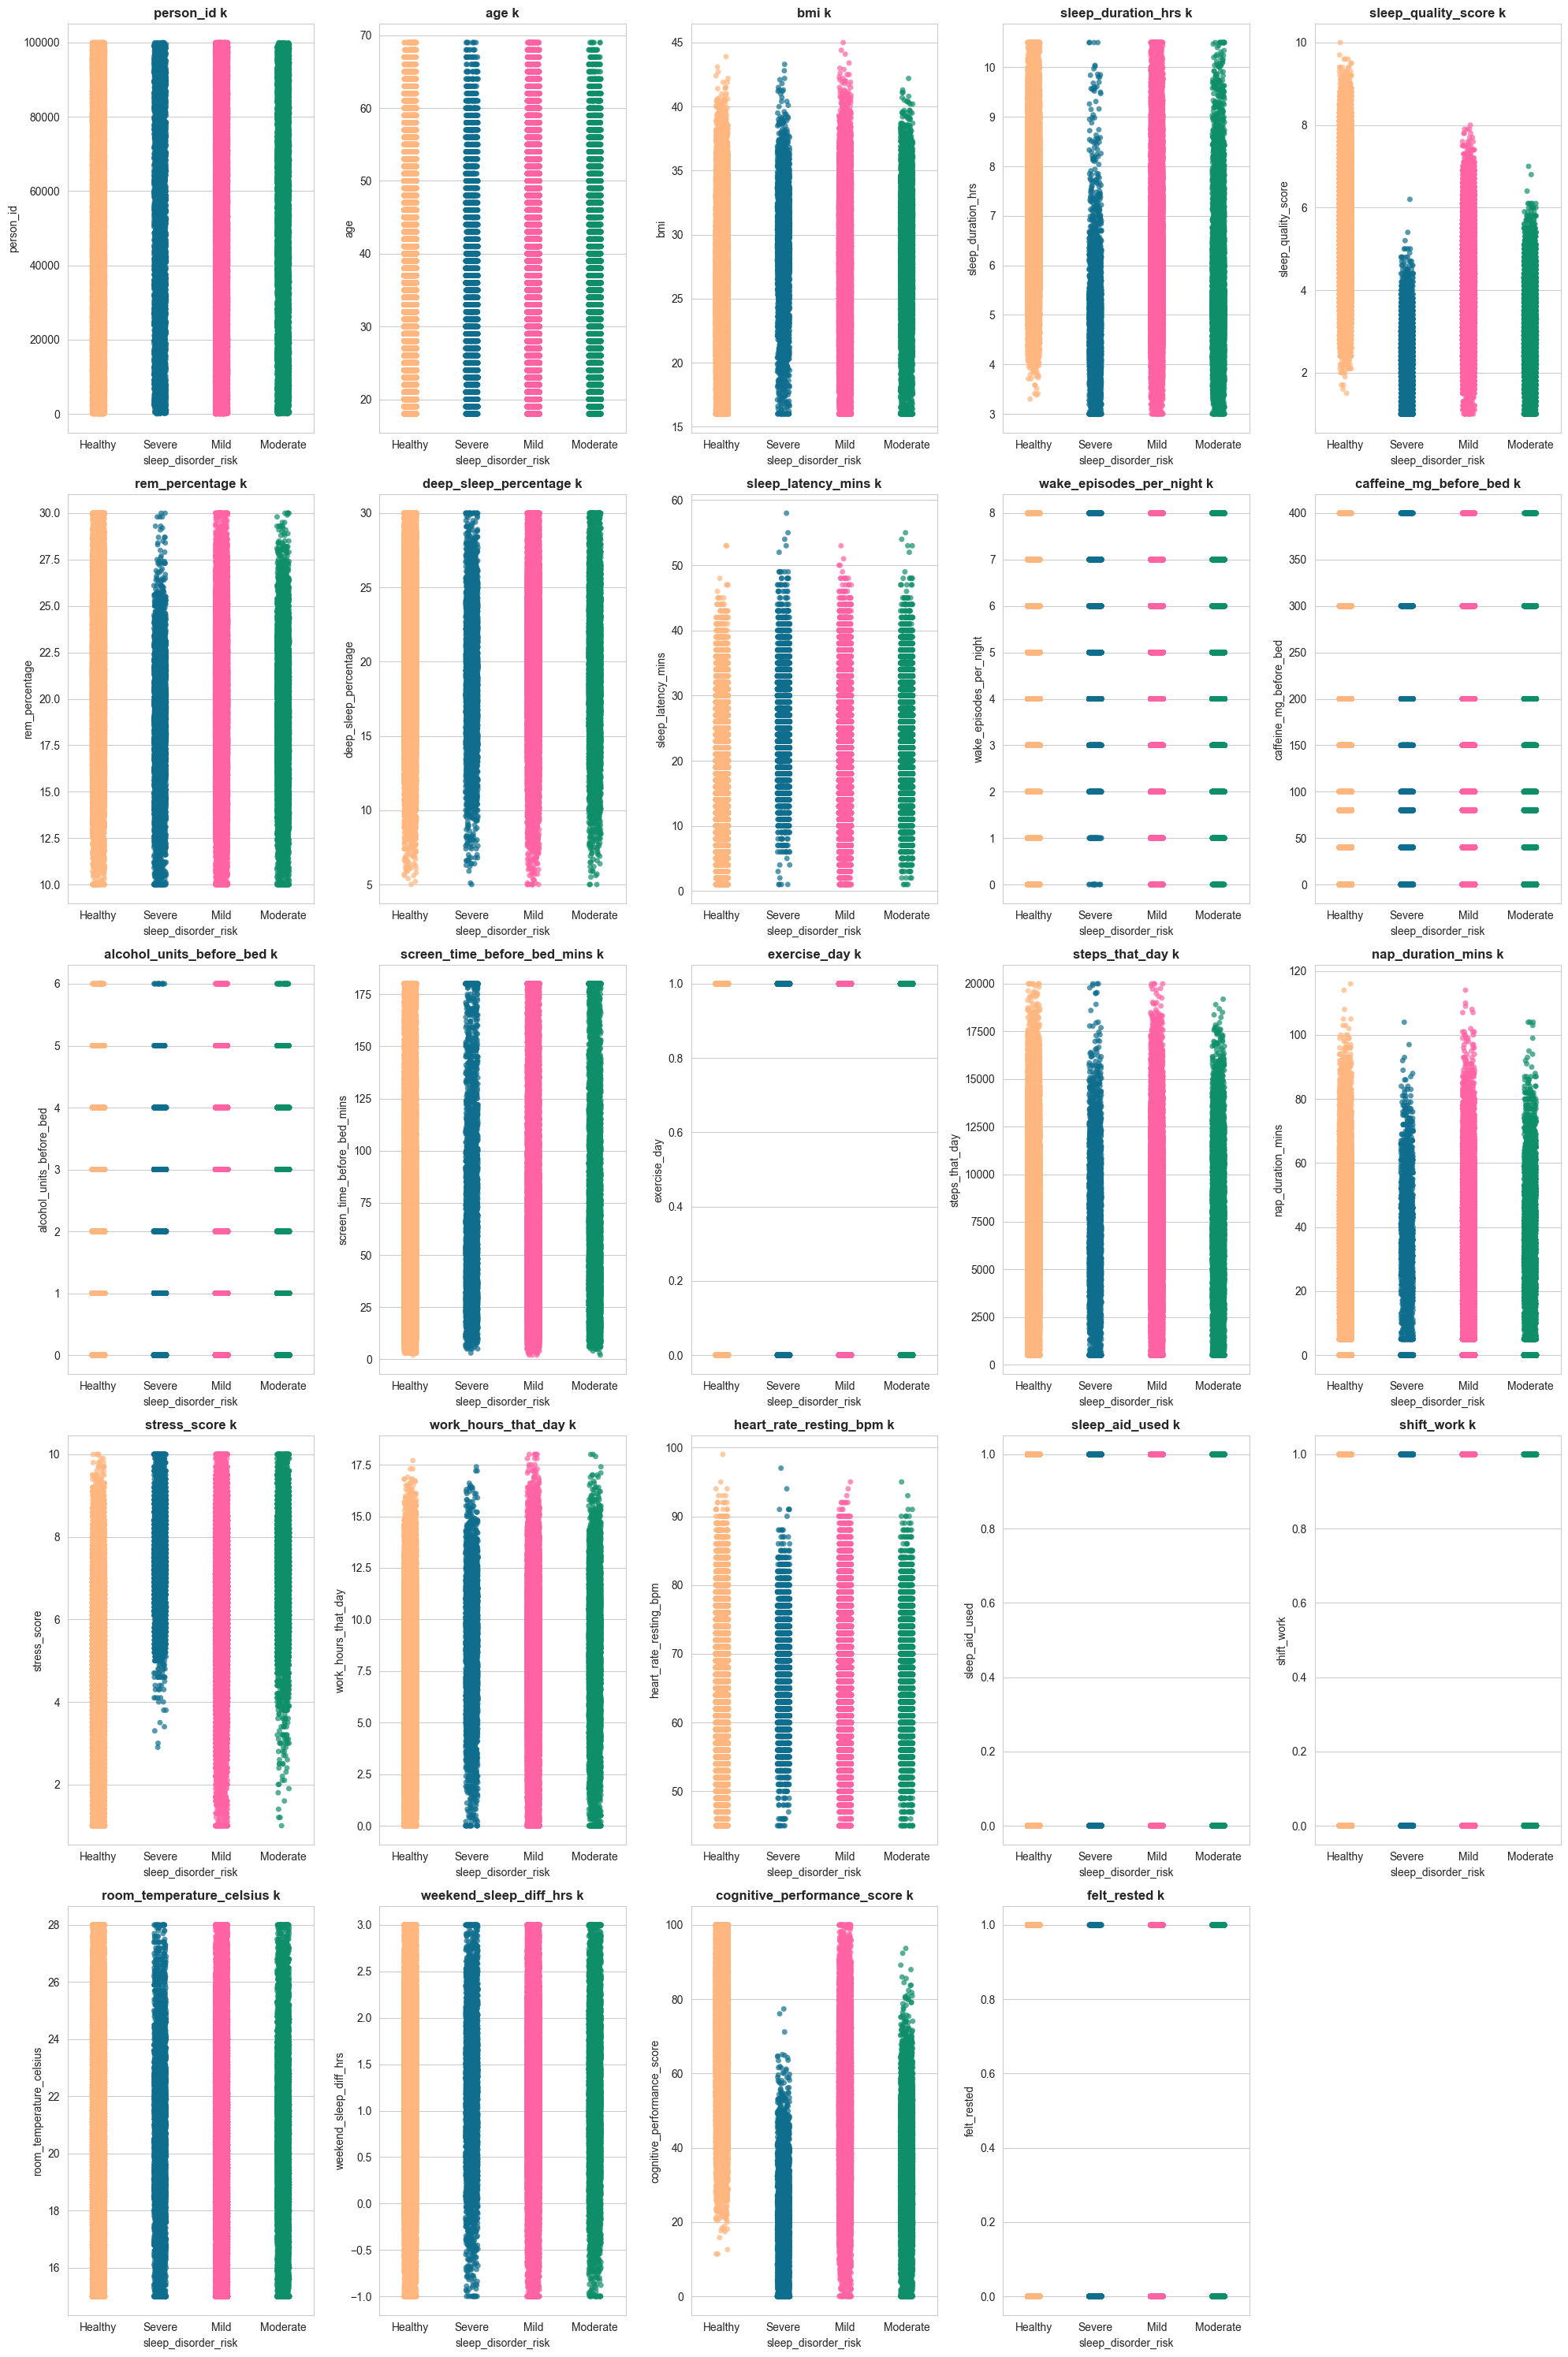

In [8]:
fig, axes = plt.subplots(5, 5, figsize=(20, 30))
axes = axes.flatten()
for i, col in enumerate(numerical):
    sns.stripplot(
        x="sleep_disorder_risk",
        y=col,
        data=df,
        jitter=True,
        alpha=0.7,
        ax=axes[i],
        palette=["#ffb67f", "#0f6e8e" , "#ff63a4", "#0f8e6a"]
    )
    axes[i].set_title(f"{col} k", fontweight="bold")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])    
plt.tight_layout()
plt.show()

<ul>
    <li>There is a clear pattern in sleep_quality_score: Individuals categorized as 'Severe' risk are predominantly clustered in the lower range of sleep quality (between 2 and 5), whereas the 'Healthy' group exhibits significantly higher scores. This makes it a strong predictive feature for the model.</li>
    <li>Crucial observation in stress_score: The 'Severe' category shows a high density of points at elevated stress levels, while the 'Healthy' category tends to have lower stress scores with a more scattered distribution. This indicates a strong positive correlation between stress levels and sleep disorder risk.</li>
</ul>

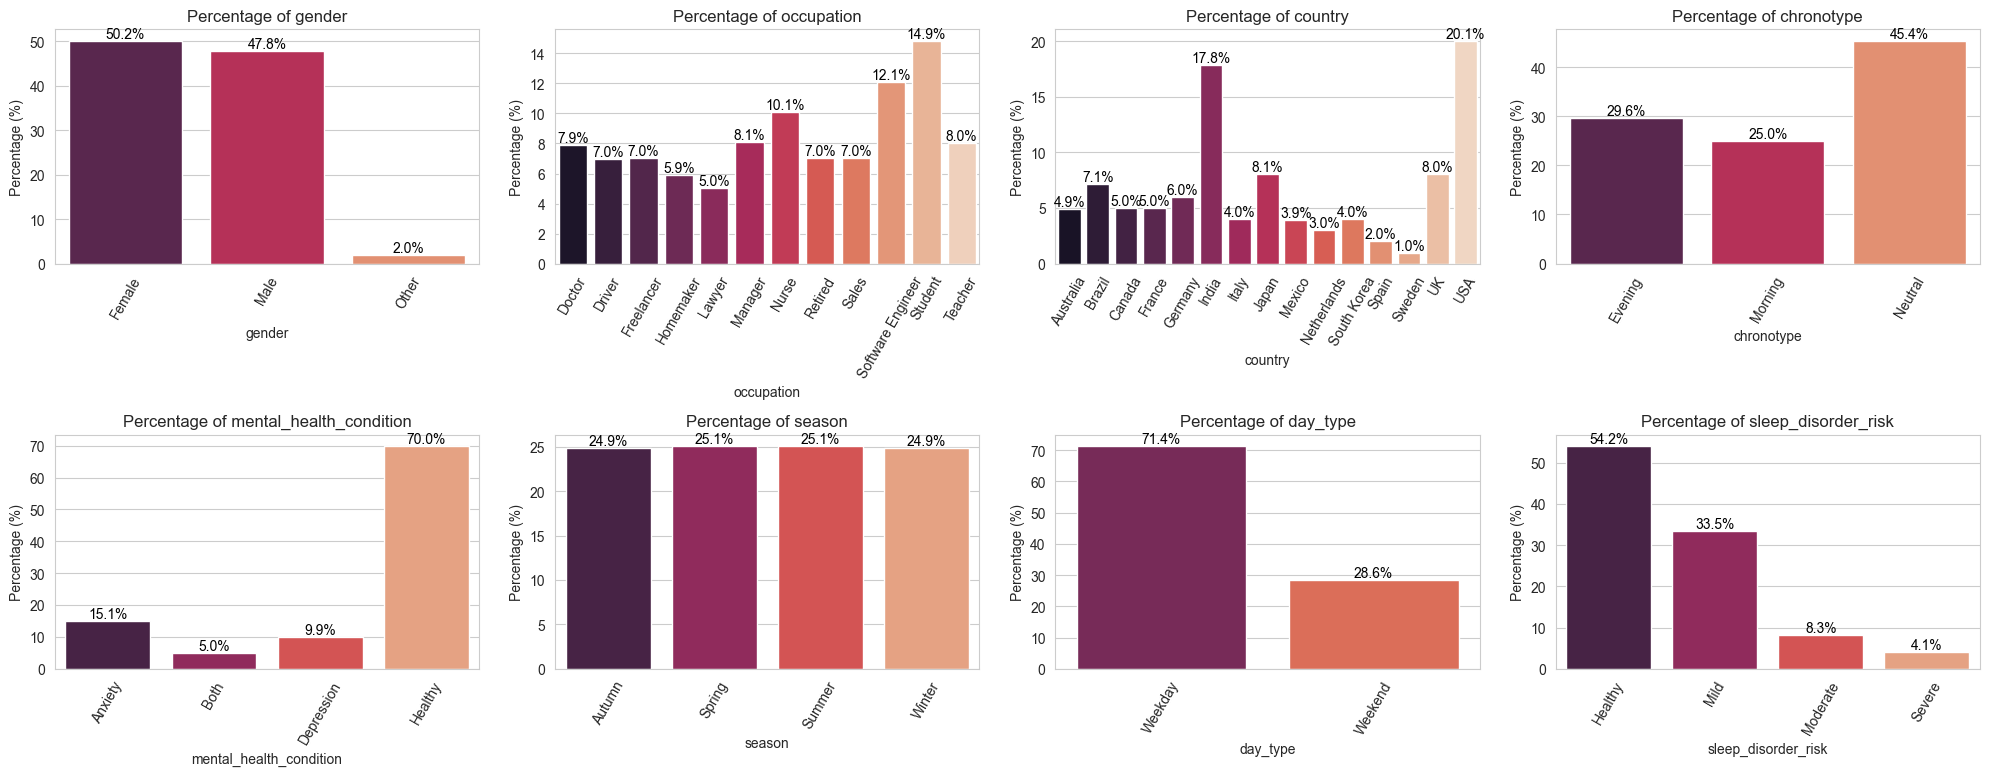

In [9]:
cat = df.select_dtypes(include=['object']).columns
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
axes = axes.flatten()
for i, col in enumerate(cat):
    counts = df[col].value_counts(normalize=True) * 100
    counts = counts.sort_index()
    ax = sns.barplot(
        x=counts.index,
        y=counts.values,
        palette="rocket",
        ax=axes[i]
    )
    axes[i].set_title(f"Percentage of {col}", fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Percentage (%)", fontsize=10)
    axes[i].tick_params(axis='x', rotation=60)
    for p, percentage in zip(ax.patches, counts.values):
        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom',
                    fontsize=10, color='black')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

<ul>
    <li>Gender appears to be a weak predictor, as it shows a near-uniform distribution across categories, suggesting minimal impact on the model's predictive power.</li>
    <li>Uniform Seasonality: The data is perfectly balanced across all four seasons, eliminating seasonal bias from the analysis.</li>
</ul>

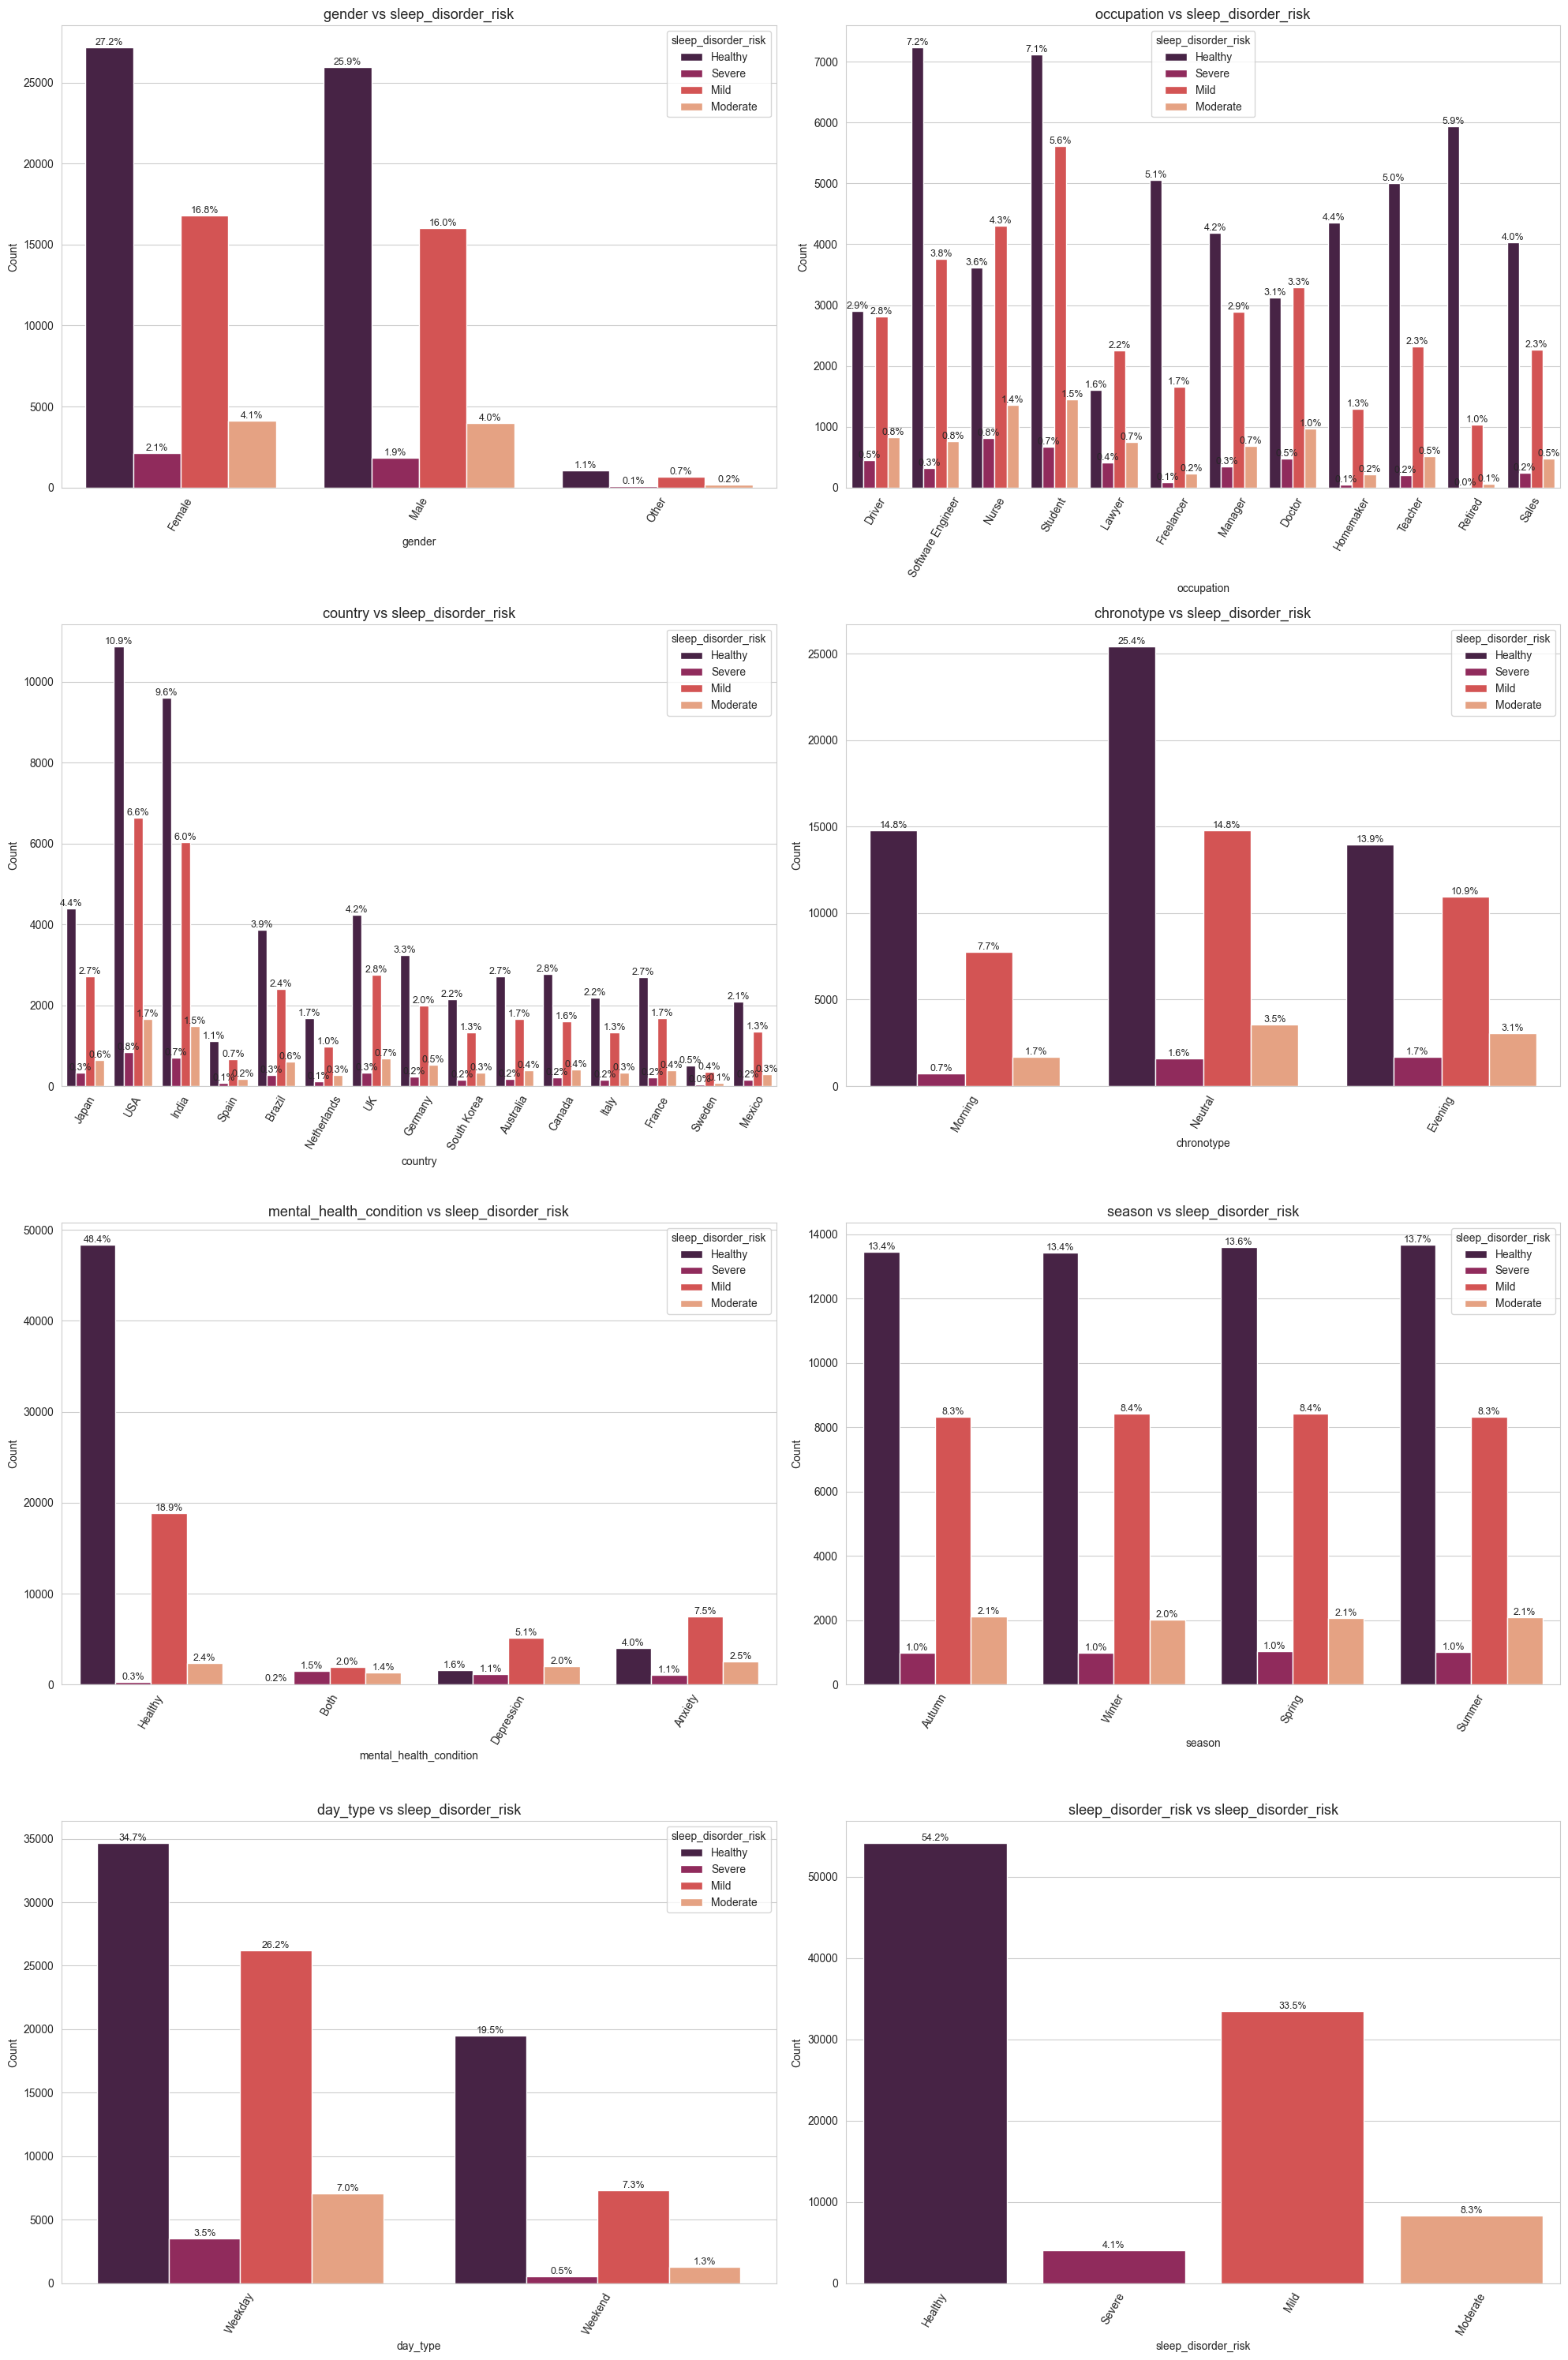

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(20, 30))
axes = axes.flatten()
for i, col in enumerate(cat):
    ax = sns.countplot(
        x=col,
        data=df,
        hue="sleep_disorder_risk",
        palette="rocket",
        ax=axes[i]
    )
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2,
                height,
                f'{height/len(df)*100:.1f}%',
                ha='center',
                va='bottom',
                fontsize=9
            )
    axes[i].set_title(f'{col} vs sleep_disorder_risk', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=60)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

<ul>
    <li>High-Risk Groups: Software Engineers, Doctors, and Nurses show a noticeably higher frequency of "Mild" and "Moderate" risks compared to other professions.</li>
    <li>Low-Risk Groups: Teachers and Retired individuals have a much higher proportion of "Healthy" status.</li>
    <li>The risk distribution is nearly identical across all seasons (Autumn, Winter, Spring, Summer). This proves that Season has no impact on sleep disorder risk in this specific dataset.</li>
    <li>Neutral types have the highest count of "Healthy" individuals. </li>
</ul>

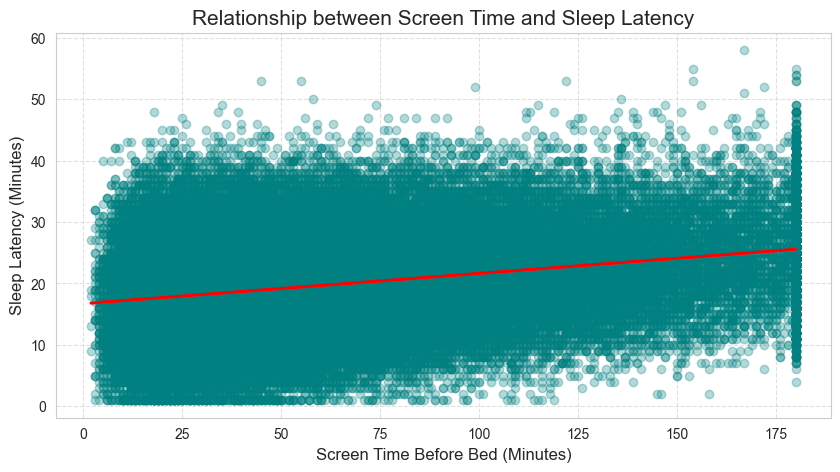

In [11]:
plt.figure(figsize=(10, 5))
sns.regplot(data=df, 
            x='screen_time_before_bed_mins', 
            y='sleep_latency_mins', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'}) 

plt.title('Relationship between Screen Time and Sleep Latency', fontsize=15)
plt.xlabel('Screen Time Before Bed (Minutes)', fontsize=12)
plt.ylabel('Sleep Latency (Minutes)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<ul>
    <li>A clear positive correlation is observed between screen time and sleep latency. As pre-sleep screen usage increases, the time required to fall asleep (latency) also rises. </li>
</ul>

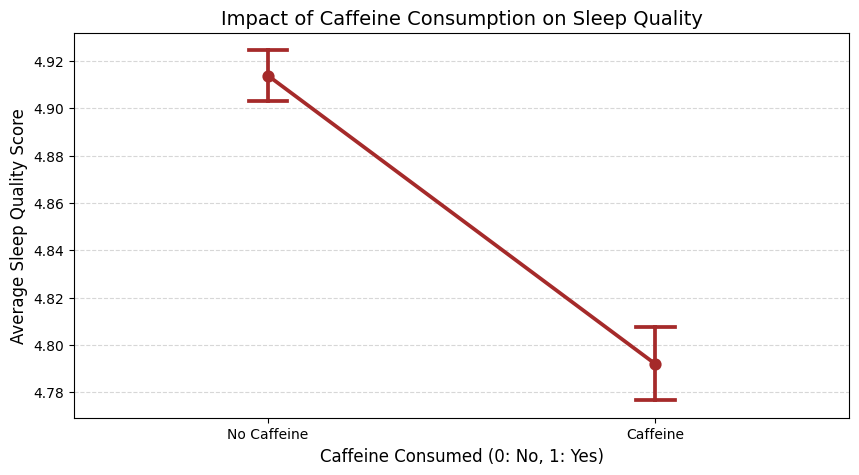

In [17]:
df['is_caffeine_consumed'] = df['caffeine_mg_before_bed'].apply(lambda x: 1 if x > 0 else 0)

plt.figure(figsize=(10, 5))
sns.pointplot(data=df, 
              x='is_caffeine_consumed', 
              y='sleep_quality_score', 
              color='brown', 
              capsize=.1) 

plt.title('Impact of Caffeine Consumption on Sleep Quality', fontsize=14)
plt.xlabel('Caffeine Consumed (0: No, 1: Yes)', fontsize=12)
plt.ylabel('Average Sleep Quality Score', fontsize=12)
plt.xticks([0, 1], ['No Caffeine', 'Caffeine']) 

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

<ul>
    <li>The point plot reveals a negative correlation between caffeine consumption and sleep quality. On average, individuals who do not consume caffeine before bed report higher sleep quality scores compared to those who do. </li>
</ul>

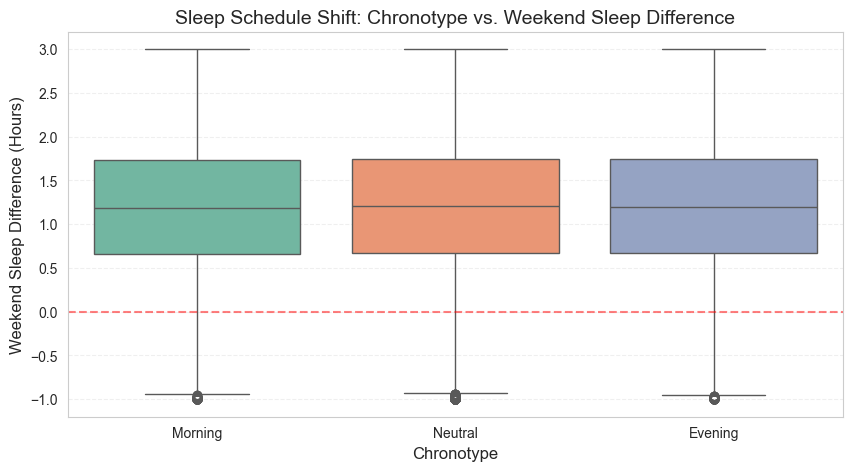

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, 
            x='chronotype', 
            y='weekend_sleep_diff_hrs', 
            palette='Set2',
            hue='chronotype', 
            legend=False)
plt.title('Sleep Schedule Shift: Chronotype vs. Weekend Sleep Difference', fontsize=14)
plt.xlabel('Chronotype', fontsize=12)
plt.ylabel('Weekend Sleep Difference (Hours)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

<ul>
    <li>there is no significant difference in weekend sleep patterns across the three chronotypes. </li>
</ul>

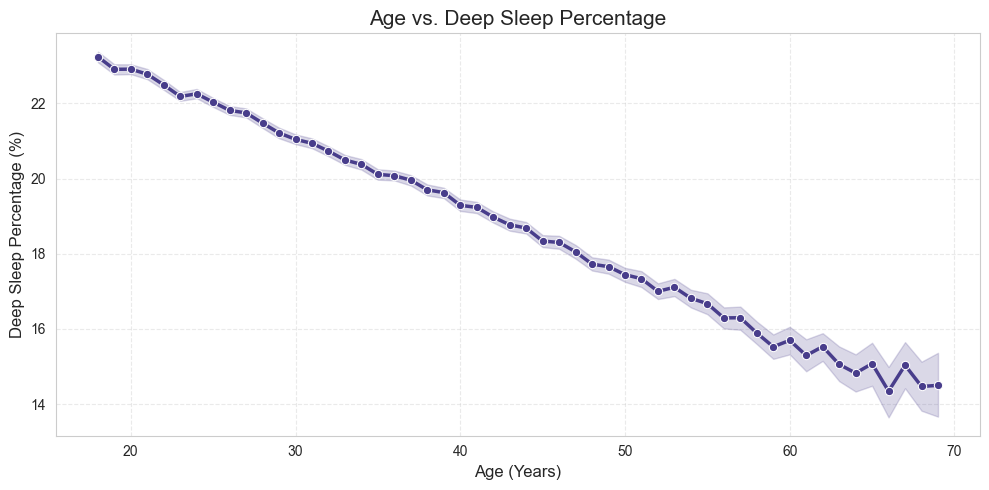

In [14]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, 
             x='age', 
             y='deep_sleep_percentage', 
             marker='o',       
             color='darkslateblue', 
             linewidth=2.5)

plt.title('Age vs. Deep Sleep Percentage', fontsize=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Deep Sleep Percentage (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

<ul>
    <li>As age increases, the percentage of deep sleep significantly declines, dropping from ~23% in the early 20s to ~14% in the late 60s. This aligns perfectly with biological sleep patterns, where the brain's ability to maintain slow-wave sleep diminishes over time. </li>
</ul>

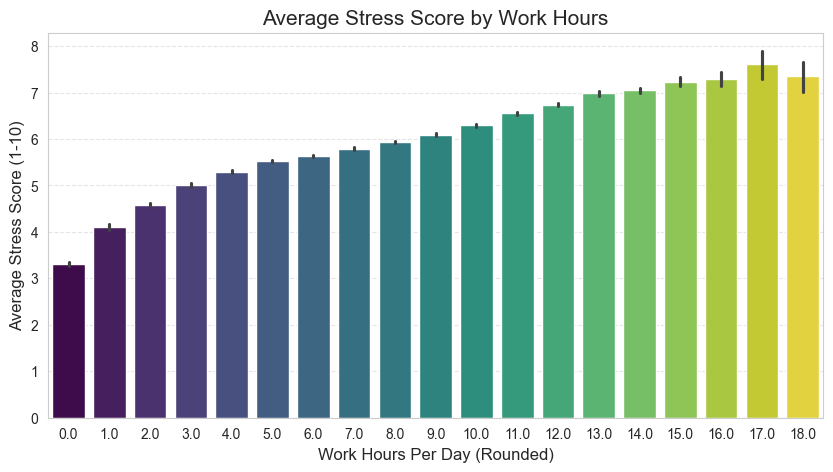

In [15]:
df['work_hours_rounded'] = df['work_hours_that_day'].round()

plt.figure(figsize=(10, 5))
sns.barplot(data=df, 
            x='work_hours_rounded', 
            y='stress_score', 
            palette='viridis', 
            hue='work_hours_rounded',
            legend=False)

plt.title('Average Stress Score by Work Hours', fontsize=15)
plt.xlabel('Work Hours Per Day (Rounded)', fontsize=12)
plt.ylabel('Average Stress Score (1-10)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

df = df.drop('work_hours_rounded', axis=1)

<ul>
    <li>The bar chart reveals a strong, near-linear positive correlation between daily work hours and average stress levels. As working hours increase from 0 to 18, the average stress score consistently climbs from ~3 to ~7.5. This steady progression identifies workload as a primary and highly predictable driver of stress within this dataset. </li>
</ul>

# Data Preprocessing

In [16]:
# Duplicates: 

df.duplicated().sum()

np.int64(0)

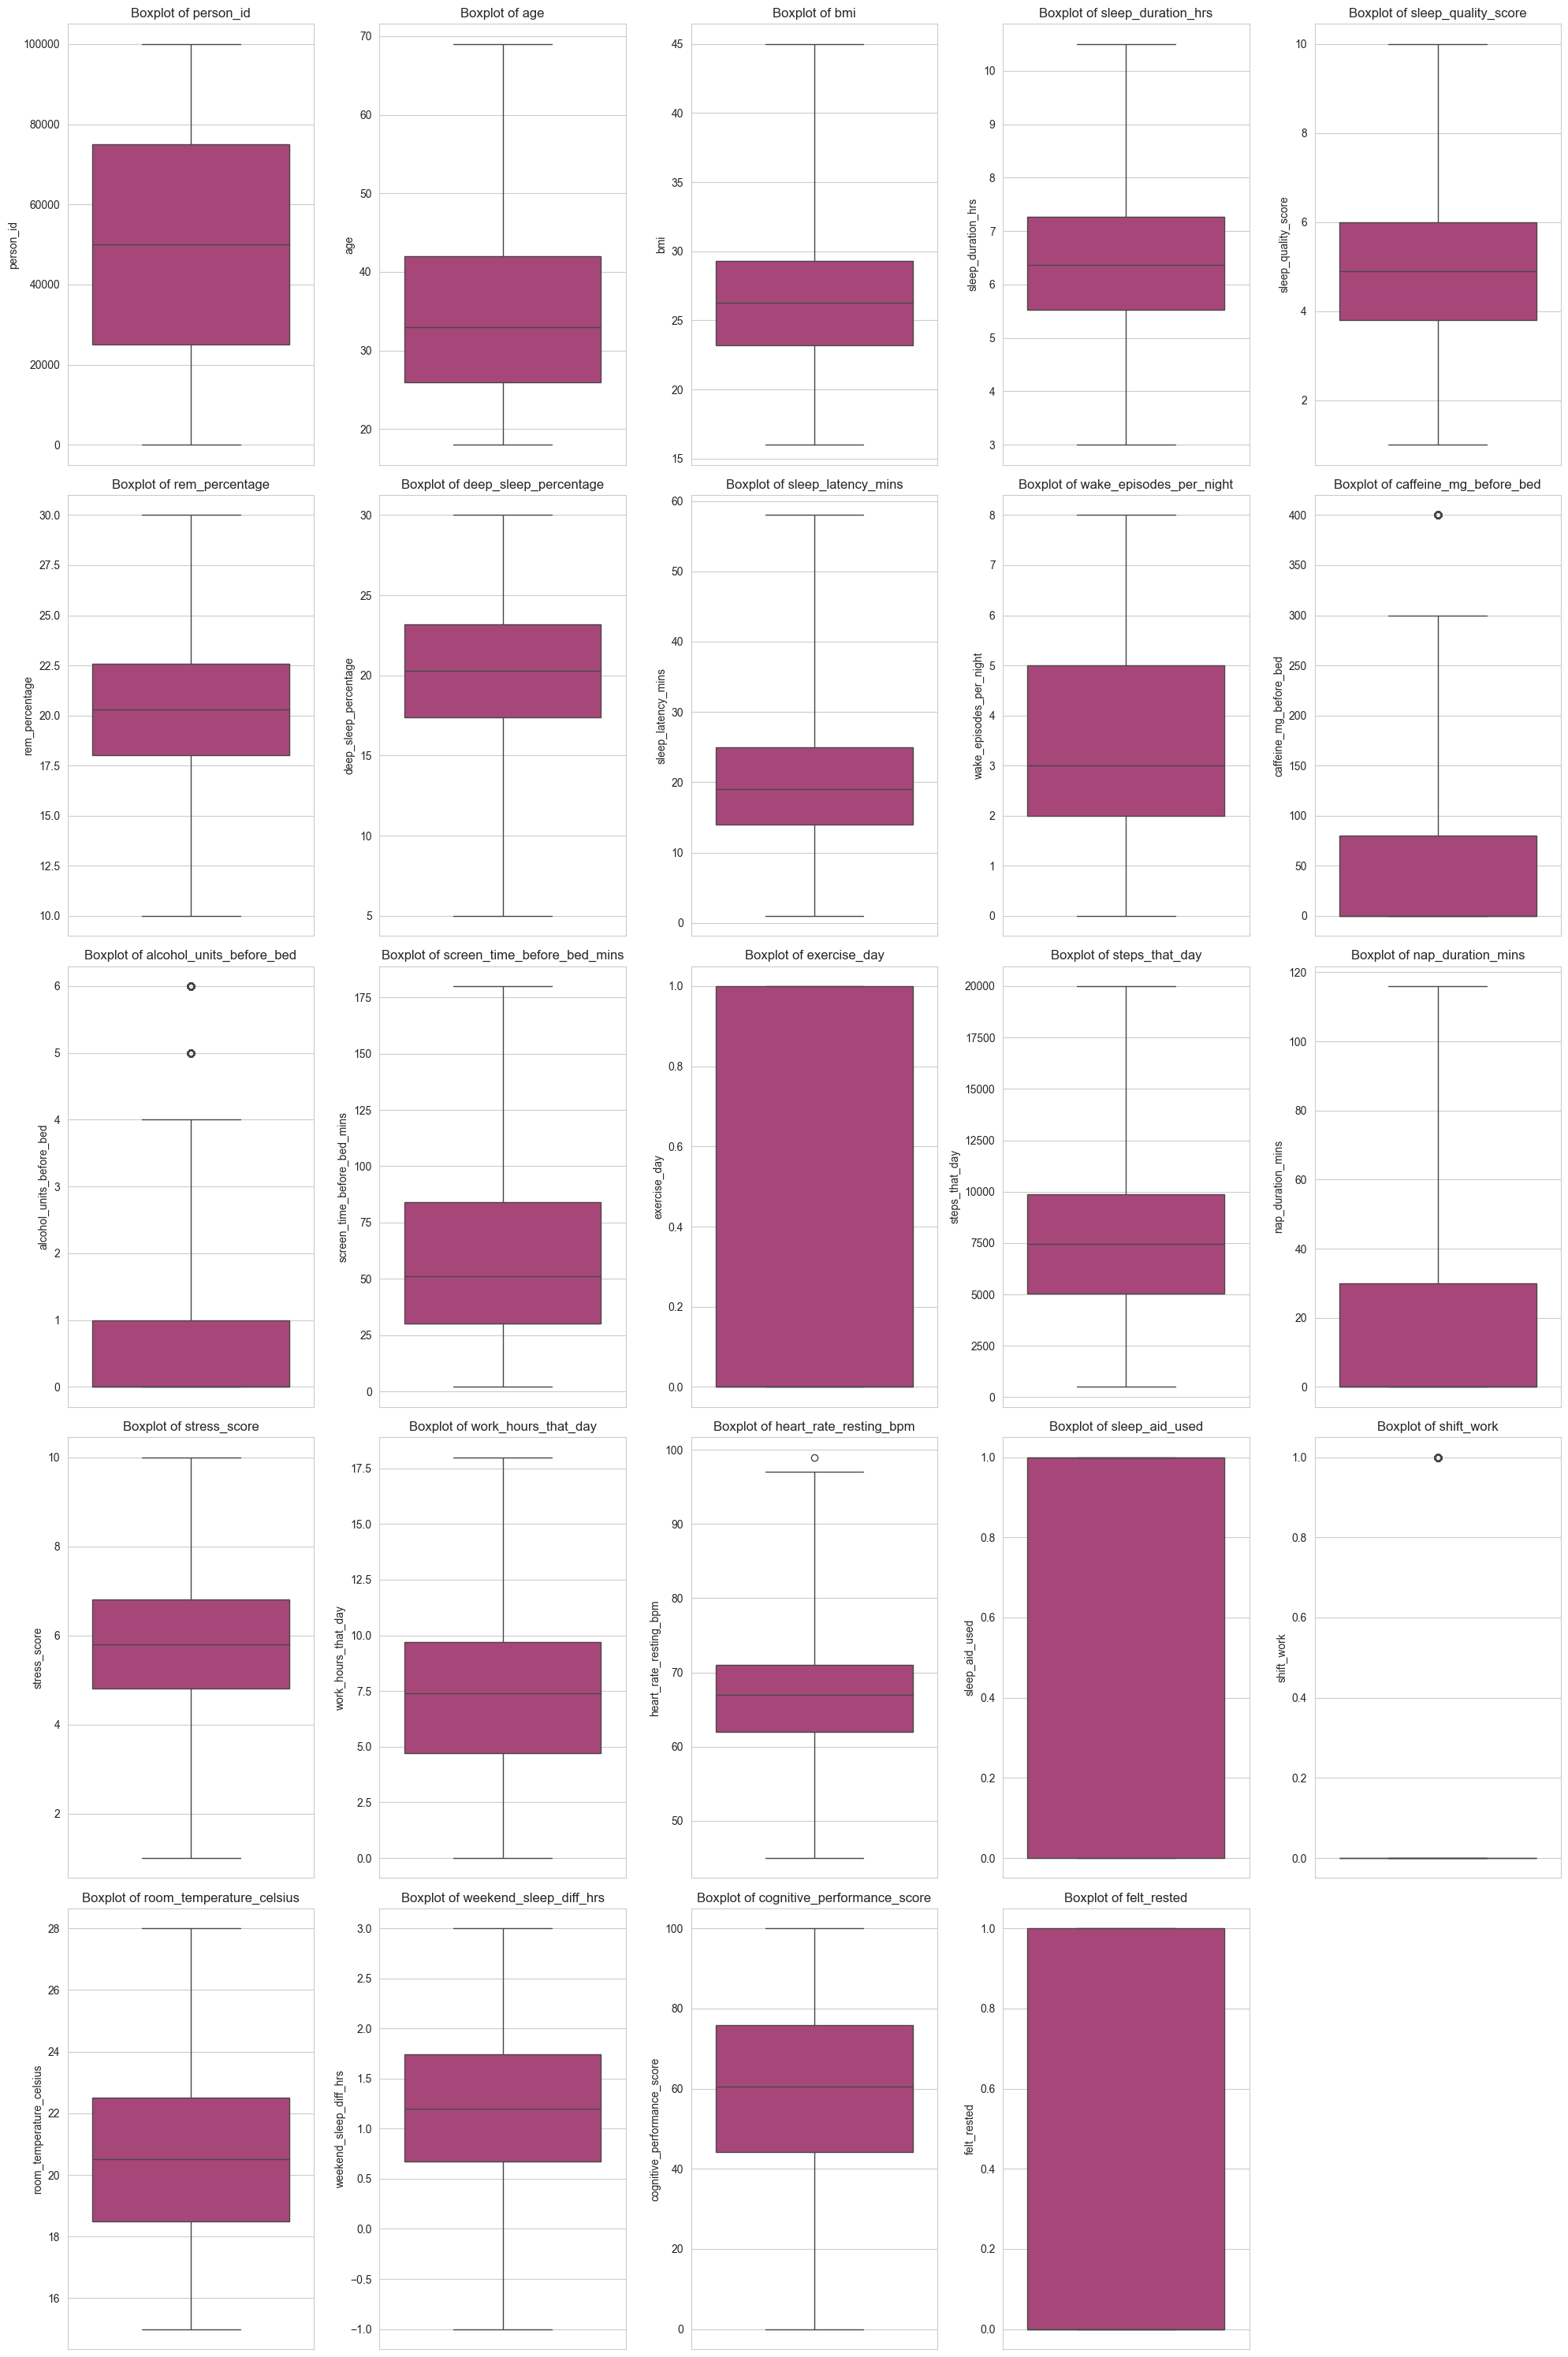

In [17]:
# check outliers
fig, axes = plt.subplots(5,5, figsize=(20, 30))
axes = axes.flatten()
for i, col in enumerate(numerical):
    sns.boxplot(data=df, y=col, ax=axes[i], palette='magma',whis=3)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<ul>
    <li>The data is representative of reality, these aren't outliers.</li>
</ul>

# Feature Engineering

In [18]:
# Drop columns decided during EDA
cols_to_drop = ['person_id', 'country', 'felt_rested', 'cognitive_performance_score']
df.drop(columns=cols_to_drop, inplace=True)

# Binarize highly-skewed consumption features (presence/absence signal is what matters)
df['is_alcohol_consumed'] = (df['alcohol_units_before_bed'] > 0).astype(int)

In [19]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls
0,age,int64,"[27, 26, 25, 23, 24, 31, 34, 28, 32, 33]",52,0,0.0
1,gender,object,"[Female, Male, Other]",3,0,0.0
2,occupation,object,"[Student, Software Engineer, Nurse, Manager, T...",12,0,0.0
3,bmi,float64,"[16.0, 25.5, 27.8, 25.6, 27.0, 25.3, 26.3, 26....",277,0,0.0
4,sleep_duration_hrs,float64,"[5.93, 6.41, 5.89, 6.19, 5.99, 6.52, 6.13, 6.4...",750,0,0.0
5,sleep_quality_score,float64,"[4.8, 5.3, 5.1, 5.0, 5.4, 4.7, 5.2, 5.6, 4.9, ...",89,0,0.0
6,rem_percentage,float64,"[20.3, 19.6, 20.7, 20.0, 19.7, 21.0, 20.5, 20....",201,0,0.0
7,deep_sleep_percentage,float64,"[30.0, 20.1, 20.2, 21.1, 20.8, 19.6, 20.4, 19....",251,0,0.0
8,sleep_latency_mins,int64,"[20, 19, 18, 16, 17, 21, 22, 15, 23, 14]",56,0,0.0
9,wake_episodes_per_night,int64,"[3, 2, 4, 1, 5, 6, 0, 7, 8]",9,0,0.0


# Split Data

In [54]:
x=df.drop(columns=['sleep_disorder_risk'])
y=df['sleep_disorder_risk']

x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=50)

# Correlation

In [21]:
# Numerical: 

num= x_train.select_dtypes(include=['float64','int64']).columns.to_list()
x = x_train[num]
y = y_train

f_values, p_values = f_classif(x, y)

anova = pd.DataFrame({
    'Feature': num,
    'F-Score': f_values,
    'P-Value': p_values
}).sort_values(by='F-Score', ascending=False)

print(anova)

                        Feature       F-Score        P-Value
3           sleep_quality_score  25922.180544   0.000000e+00
14                 stress_score   8681.552487   0.000000e+00
2            sleep_duration_hrs   7855.549557   0.000000e+00
7       wake_episodes_per_night   3853.743092   0.000000e+00
6            sleep_latency_mins   3290.481661   0.000000e+00
1                           bmi   1654.094787   0.000000e+00
15          work_hours_that_day   1638.923876   0.000000e+00
18                   shift_work   1598.189969   0.000000e+00
4                rem_percentage   1166.748527   0.000000e+00
9      alcohol_units_before_bed    311.904485  2.382403e-201
5         deep_sleep_percentage    293.995268  7.945095e-190
8        caffeine_mg_before_bed    249.804819  2.301995e-161
22          is_alcohol_consumed    132.561520   1.146997e-85
0                           age    110.010503   4.401819e-71
10  screen_time_before_bed_mins    103.550480   6.640013e-67
21         is_caffeine_c

In [22]:

categorical= x_train.select_dtypes(include=['object']).columns.to_list()
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(table)
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

for col in categorical:
    cv = cramers_v(x_train[col], y_train)
    print(f"Feature: {col}, Cramér's V: {cv:.4f}")

Feature: gender, Cramér's V: 0.0076
Feature: occupation, Cramér's V: 0.1751
Feature: chronotype, Cramér's V: 0.0734
Feature: mental_health_condition, Cramér's V: 0.3303
Feature: season, Cramér's V: 0.0053
Feature: day_type, Cramér's V: 0.1866


In [55]:

col_drop=['room_temperature_celsius','weekend_sleep_diff_hrs','exercise_day','steps_that_day','heart_rate_resting_bpm','alcohol_units_before_bed',
                 'gender','chronotype','season', 'caffeine_mg_before_bed']

x_train.drop(col_drop,axis=1,inplace=True)
x_test.drop(col_drop,axis=1,inplace=True)

binary_cols = [ 'sleep_aid_used', 'shift_work', 'is_caffeine_consumed', 'is_alcohol_consumed']
numerical_cols = ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'deep_sleep_percentage','sleep_latency_mins', 'screen_time_before_bed_mins',
                  'nap_duration_mins', 'stress_score', 'work_hours_that_day' ]
nominal_cols = ['occupation','day_type']
ordinal_cols = ['mental_health_condition']

# Scalling

In [56]:
scaler = StandardScaler()
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

# Encoding

In [57]:
mental_health_mapping = {
    'Healthy': 0,
    'Anxiety': 1,
    'Depression': 2,
    'Both': 3
}

x_train['mental_health_condition'] = x_train['mental_health_condition'].map(mental_health_mapping)
x_test['mental_health_condition'] = x_test['mental_health_condition'].map(mental_health_mapping)

In [58]:
day_type_mapping = {
    'Weekend': 0,
    'Weekday': 1,
}

x_train['day_type'] = x_train['day_type'].map(day_type_mapping)
x_test['day_type'] = x_test['day_type'].map(day_type_mapping)

In [59]:
le = LabelEncoder()
x_train['occupation'] = le.fit_transform(x_train['occupation'])
x_test['occupation'] = le.transform(x_test['occupation'])

In [60]:
le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train)
y_test = le_target.transform(y_test)

In [61]:
data_info(x_train)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls
0,age,float64,"[-0.6983316239615347, -0.7890060844043087, -0....",52,0,0.0
1,occupation,int64,"[10, 9, 6, 5, 11, 0, 7, 2, 8, 1]",12,0,0.0
2,bmi,float64,"[-2.2944394015642993, 0.33805557984154894, -0....",274,0,0.0
3,sleep_duration_hrs,float64,"[-0.01585162310797003, 0.03899455603496593, 0....",748,0,0.0
4,sleep_quality_score,float64,"[-0.05079566988009219, 0.08200997714206192, 0....",89,0,0.0
5,rem_percentage,float64,"[20.0, 21.0, 20.3, 19.6, 20.7, 21.3, 21.1, 20....",201,0,0.0
6,deep_sleep_percentage,float64,"[2.293530244529517, -0.039018953670804046, 0.0...",251,0,0.0
7,sleep_latency_mins,float64,"[0.02198696295978591, -0.10977998863081014, -0...",56,0,0.0
8,wake_episodes_per_night,int64,"[3, 2, 4, 1, 5, 6, 0, 7, 8]",9,0,0.0
9,screen_time_before_bed_mins,float64,"[2.615465702967337, -0.775616232747981, -0.865...",179,0,0.0


# Balancing The Data

In [29]:
print(y_train[y_train==0].shape)
print(y_train[y_train==1].shape)
print(y_train[y_train==2].shape)
print(y_train[y_train==3].shape)

(43388,)
(26802,)
(6586,)
(3224,)


In [30]:
"""under_strategy = {0: 20000, 1: 20000}
rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
x_temp, y_temp = rus.fit_resample(x_train, y_train)

over_strategy = {2: 20000, 3: 20000}
smote = SMOTE(sampling_strategy=over_strategy, random_state=42)
x_train, y_train = smote.fit_resample(x_temp, y_temp)

print(pd.Series(y_train).value_counts())"""

'under_strategy = {0: 20000, 1: 20000}\nrus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)\nx_temp, y_temp = rus.fit_resample(x_train, y_train)\n\nover_strategy = {2: 20000, 3: 20000}\nsmote = SMOTE(sampling_strategy=over_strategy, random_state=42)\nx_train, y_train = smote.fit_resample(x_temp, y_temp)\n\nprint(pd.Series(y_train).value_counts())'

# Model training 

## Logistic

In [31]:
'''

log = LogisticRegression(max_iter=1000, random_state=50)

param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']  
}

grid_search = GridSearchCV(
    estimator=log,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)
best_log_reg = grid_search.best_estimator_

y_pred = best_log_reg.predict(x_test)
y_pred_train = best_log_reg.predict(x_train)

print("Best Parameters:", grid_search.best_params_)
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred)) 

'''

'\n\nlog = LogisticRegression(max_iter=1000, random_state=50)\n\nparam_grid = {\n    \'penalty\': [\'l1\', \'l2\'],\n    \'C\': [0.01, 0.1, 1, 10, 100],\n    \'class_weight\': [None, \'balanced\']  \n}\n\ngrid_search = GridSearchCV(\n    estimator=log,\n    param_grid=param_grid,\n    cv=5,\n    scoring=\'accuracy\',\n    n_jobs=-1,\n    verbose=1\n)\n\ngrid_search.fit(x_train, y_train)\nbest_log_reg = grid_search.best_estimator_\n\ny_pred = best_log_reg.predict(x_test)\ny_pred_train = best_log_reg.predict(x_train)\n\nprint("Best Parameters:", grid_search.best_params_)\nprint("Train Accuracy:", accuracy_score(y_train, y_pred_train))\nprint("Test Accuracy:", accuracy_score(y_test, y_pred)) \n\n'

In [12]:
log_final=LogisticRegression(C= 100, class_weight=None, penalty='l2', random_state=50)

log_final.fit(x_train,y_train)

y_pred = log_final.predict(x_test)
y_pred_train = log_final.predict(x_train)

print(classification_report(y_test, y_pred))
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91     10768
           1       0.75      0.78      0.76      6677
           2       0.54      0.39      0.45      1713
           3       0.65      0.61      0.63       842

    accuracy                           0.81     20000
   macro avg       0.71      0.67      0.69     20000
weighted avg       0.81      0.81      0.81     20000

Train Accuracy: 0.815425
Test Accuracy: 0.81235


## Decision Tree

In [13]:
dt= DecisionTreeClassifier(random_state=50)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, 15],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [15, 20, 25],
    'class_weight': [None, 'balanced']
}
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(x_train, y_train)
best_dt = grid_search.best_estimator_

y_pred = best_dt.predict(x_test)
y_pred_train = best_dt.predict(x_train)

print("Best Parameters:", grid_search.best_params_)
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 15, 'min_samples_split': 10}
Train Accuracy: 0.9277875
Test Accuracy: 0.8959


In [14]:
dt= DecisionTreeClassifier(criterion='entropy', max_depth=15, min_samples_leaf=15,
                            min_samples_split=10, class_weight= None, random_state=50)

dt.fit(x_train, y_train)

y_pred_final = dt.predict(x_test)
y_pred_train_final = dt.predict(x_train)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_final))
print("Test Accuracy:", accuracy_score(y_test, y_pred_final))

print(classification_report(y_test, y_pred_final))

Train Accuracy: 0.9277875
Test Accuracy: 0.8959
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     10768
           1       0.87      0.88      0.88      6677
           2       0.63      0.60      0.61      1713
           3       0.77      0.71      0.74       842

    accuracy                           0.90     20000
   macro avg       0.81      0.79      0.80     20000
weighted avg       0.89      0.90      0.89     20000



## Random Forest

In [ ]:
"""rf= RandomForestClassifier(random_state=50)

param_grid = {
    'n_estimators': [100, 200, 300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [15, 20, 25],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(x_test)
y_pred_train = best_rf.predict(x_train)

print("Best Parameters:", grid_search.best_params_)
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred)) """

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


In [ ]:
rf_final = RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_leaf=15,
                                  min_samples_split=10 , n_estimators=200, class_weight=None, random_state=42)
rf_final.fit(x_train, y_train)

y_pred_final = rf_final.predict(x_test)
y_pred_train_final = rf_final.predict(x_train)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_final))
print("Test Accuracy:", accuracy_score(y_test, y_pred_final))

print(classification_report(y_test, y_pred_final))

Train Accuracy: 0.93295
Test Accuracy: 0.90155
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     10768
           1       0.86      0.91      0.88      6677
           2       0.69      0.53      0.60      1713
           3       0.87      0.67      0.76       842

    accuracy                           0.90     20000
   macro avg       0.85      0.77      0.80     20000
weighted avg       0.90      0.90      0.90     20000



## XGBoost

In [ ]:
"""xgb= XGBClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [10, 20],
    'min_child_weight': [10, 15, 20],
    'gamma': [0, 0.1, 0.2],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)
best_xgb = grid_search.best_estimator_

y_pred = best_xgb.predict(x_test)
y_pred_train = best_xgb.predict(x_train)

print("Best Parameters:", grid_search.best_params_)
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred))"""

In [62]:
xgb_final = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=100,
                          colsample_bytree=0.8, gamma=0.1, class_weight=None, random_state=42)
xgb_final.fit(x_train, y_train)

y_pred_final = xgb_final.predict(x_test)
y_pred_train_final = xgb_final.predict(x_train)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_final))
print("Test Accuracy:", accuracy_score(y_test, y_pred_final))

print(classification_report(y_test, y_pred_final))

Train Accuracy: 0.9371625
Test Accuracy: 0.92465
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     10768
           1       0.90      0.93      0.91      6677
           2       0.72      0.60      0.66      1713
           3       0.87      0.74      0.80       842

    accuracy                           0.92     20000
   macro avg       0.86      0.81      0.84     20000
weighted avg       0.92      0.92      0.92     20000



# save Model

In [65]:
import joblib

joblib.dump(xgb_final, 'sleep_health_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

joblib.dump(le, 'encoder_occupation.pkl')

joblib.dump(le_target, 'encoder_target.pkl')

['encoder_target.pkl']